In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
import sys 
import json 

In [9]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.utils.utils import demand_fill_time_template, split_train_test_time, demand_feature_engineering, impute_missing_values

In [2]:
data = pd.read_csv('../data/demands_sgn.csv', index_col=0)

In [6]:
data.rename(columns = {'origin_block_start_time':'block_start_time'},inplace=True)

In [7]:
data.head(4)

,order_date,block_start_time,hex_id,service_id,total_demands,order_last_1day,percentage,tier
0,2025-11-01,2025-11-01 11:50:00,8765b565cffffff,SGN-TRICYCLE,1,2.0,1.253108,TOP
1,2025-11-01,2025-11-01 13:10:00,8765b566effffff,SGN-TRICYCLE,1,4.0,2.784684,TOP
2,2025-11-01,2025-11-01 13:50:00,8765b564bffffff,SGN-TRUCK-1000,1,NaN,0.708603,MIDDLE
3,2025-11-01,2025-11-01 14:00:00,8765b566cffffff,SGN-TRUCK-500,1,NaN,1.919443,TOP


In [49]:
data_filter = data[['block_start_time','hex_id','service_id','total_demands','order_last_1day']]
df_template = demand_fill_time_template(data_filter, data_filter['block_start_time'].min(), data_filter['block_start_time'].max(), '10min')
data_eng = demand_feature_engineering(df_template)


In [ ]:
data_imp = impute_missing_values(data_eng)


In [52]:
data_imp.shape

(100244, 26)

In [53]:
train_df, test_df = split_train_test_time(data_imp, 0.8, 1)

2025-11-02 → 2026-01-13
2026-01-14 → 2026-02-01


#### XGBoost:

In [55]:
train_encode_df = pd.get_dummies(train_df, columns = ['service_id'])
train_encode_df.drop(columns = ['block_start_time','hex_id','date'],inplace=True)

In [56]:
X = train_encode_df.drop(columns = ['total_demands'])
y = train_encode_df['total_demands']

In [57]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

xgb_model_peak = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_peak.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [58]:
test_encode_df = pd.get_dummies(test_df, columns = ['service_id'])
test_encode_df.drop(columns = ['block_start_time','hex_id','date'],inplace=True)

In [59]:
X_test = test_encode_df.drop(columns = ['total_demands'])
y_test = test_encode_df['total_demands']

y_pred = xgb_model_peak.predict(X_test)

In [60]:
def wape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return (
        np.sum(np.abs(y_true - y_pred))
        / np.sum(np.abs(y_true))
    ) * 100

In [61]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2:", r2)
print("MSE:", mse)

wape_value = wape(y_test, y_pred)
print(wape_value)

R2: -0.009661411561075361
MSE: 0.15004975271723237
18.97374330336122


#### Evaluate Testing: 

In [62]:
test_df['y_pred'] = y_pred
test_df.head(3)

,hex_id,service_id,block_start_time,total_demands,order_last_1day,date,month,weekday,hour,week_of_month,...,ma_3,ma_6,ratio_to_mean,std_3,hour_sin,hour_cos,weekday_sin,weekday_cos,is_peak,y_pred
21839,8765b5643ffffff,SGN-TRICYCLE,2026-01-14 08:00:00,1.0,4.0,2026-01-14,1,2,8,2,...,0.0,0.0,0.0,0.0,0.866025,-0.5,0.974928,-0.222521,1,1.087419
14956,8765b562affffff,SGN-TRUCK-ECO-500,2026-01-14 08:00:00,1.0,2.0,2026-01-14,1,2,8,2,...,0.0,0.0,0.0,0.0,0.866025,-0.5,0.974928,-0.222521,1,1.072292
49853,8765b5658ffffff,SGN-TRICYCLE,2026-01-14 08:00:00,1.0,2.0,2026-01-14,1,2,8,2,...,0.0,0.0,0.0,0.0,0.866025,-0.5,0.974928,-0.222521,1,1.101365


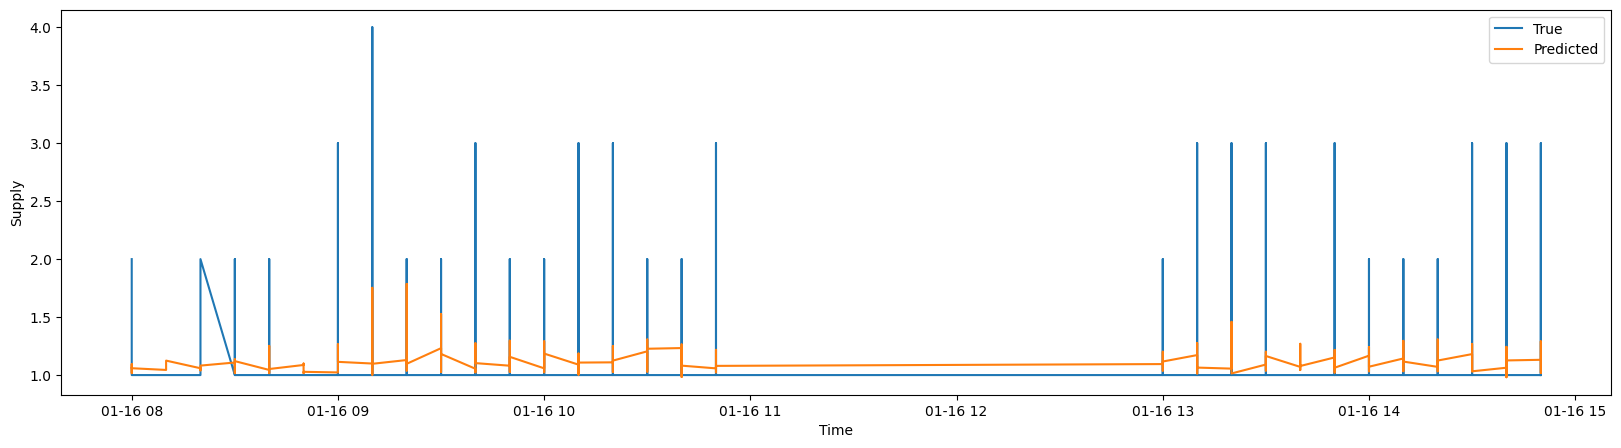

In [63]:
# plot_df = test_df[test_df['hex_id']=='8765b5644ffffff']

# plot_df = test_df[test_df['vehicle_type_TRICYCLE']==True]
test_df['date'] = pd.to_datetime(test_df['date'])

plot_df = test_df.copy()
plot_df = plot_df[plot_df['date']=='2026-01-16']

plt.figure(figsize=(20, 5))
plt.plot(plot_df['block_start_time'], plot_df['total_demands'], label='True')
plt.plot(plot_df['block_start_time'], plot_df['y_pred'], label='Predicted')
plt.xlabel('Time')
plt.ylabel('Supply')
plt.legend()
plt.show()

/var/folders/f5/j3qvvd4923z_49cvx7kg0qnh0000gn/T/ipykernel_33934/1452155227.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='Blues_d')


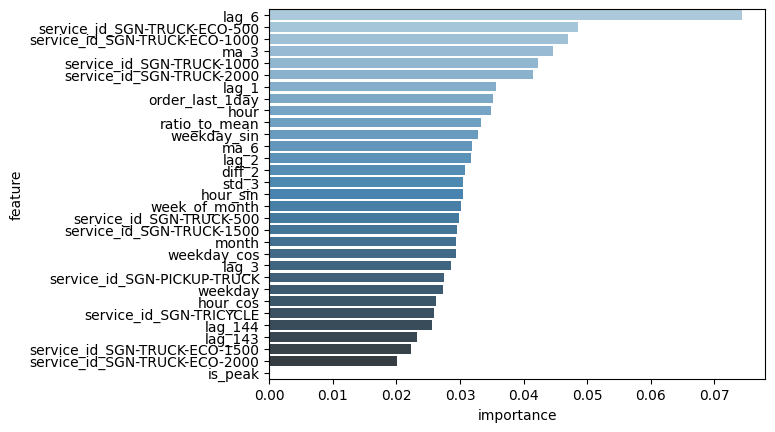

In [64]:
importance = xgb_model_peak.feature_importances_

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feat_imp, palette='Blues_d')
plt.show()

#### Random Forest: 

In [65]:
from sklearn.ensemble import RandomForestRegressor

In [66]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X, y)

# Prediction
y_pred_rf = rf_model.predict(X_test)

In [67]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)

print("R2:", r2)
print("MSE:", mse)

wape_value = wape(y_test, y_pred_rf)
print(wape_value)

R2: 0.003138361939843737
MSE: 0.14814752804403228
19.896655339238613


#### Try a batch of model: 

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


random_state = 42
models = {

        "Linear Regression": LinearRegression(),

        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1
        ),

        "Gradient Boosting": GradientBoostingRegressor(
            random_state=random_state
        ),

        "SVM": SVR(),

        "XGBoost": XGBRegressor(
            random_state=random_state,
            n_estimators=200,
            verbosity=0
        ),

        "LightGBM": LGBMRegressor(
            random_state=random_state,
            n_estimators=200,
            verbose=-1
        ),

        "CatBoost": CatBoostRegressor(
            random_state=random_state,
            verbose=0
        )
    }

In [69]:
results = []

trained_models = {}

for model_name, model in models.items():

    print(f"Training {model_name}...")

    model.fit(X, y)

    preds = model.predict(X_test)

    rmse = mean_squared_error(
        y_test,
        preds,
        # squared=False
    )

    mae = mean_absolute_error(
        y_test,
        preds
    )

    r2 = r2_score(
        y_test,
        preds
    )

    smape_score = wape(
        y_test.values,
        preds
    )

    results.append({
        "Model": model_name,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R2": round(r2, 4),
        "SMAPE": round(smape_score, 4)
    })

    trained_models[model_name] = model

# =========================
# Result Table
# =========================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

Training Linear Regression...
Training Random Forest...


/Users/naaani/Documents/ahm/TRUCK-SURGE/supply_forecasting/supply_forecast/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/naaani/Documents/ahm/TRUCK-SURGE/supply_forecasting/supply_forecast/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/naaani/Documents/ahm/TRUCK-SURGE/supply_forecasting/supply_forecast/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Training Gradient Boosting...
Training SVM...
Training XGBoost...
Training LightGBM...
Training CatBoost...


In [70]:
results_df

,Model,RMSE,MAE,R2,SMAPE
0,Linear Regression,0.1478,0.2104,0.0057,18.6955
1,Gradient Boosting,0.1481,0.2171,0.0036,19.2905
2,SVM,0.1493,0.2037,-0.0044,18.0965
3,LightGBM,0.1497,0.2157,-0.0070,19.1617
4,CatBoost,0.1501,0.2106,-0.0097,18.7144
5,XGBoost,0.1610,0.2209,-0.0834,19.6257
6,Random Forest,0.1679,0.2530,-0.1295,22.4830


#### TOP

In [72]:
data_top = data[data['tier']=='TOP']
data_top.head(1)

,order_date,block_start_time,hex_id,service_id,total_demands,order_last_1day,percentage,tier
0,2025-11-01,2025-11-01 11:50:00,8765b565cffffff,SGN-TRICYCLE,1,2.0,1.253108,TOP


In [73]:
data_top_filter = data_top[['block_start_time','hex_id','service_id','total_demands','order_last_1day']]
df_top_template = demand_fill_time_template(data_top_filter, data_top_filter['block_start_time'].min(), data_top_filter['block_start_time'].max(), '10min')
data_top_eng = demand_feature_engineering(df_top_template)


In [93]:
data_top_imp = impute_missing_values(data_top_eng)
train_df, test_df = split_train_test_time(data_top_imp, 0.8, 1)

2025-11-02 → 2026-01-13
2026-01-14 → 2026-02-01


In [94]:
train_encode_df = pd.get_dummies(train_df, columns = ['service_id'])
train_encode_df.drop(columns = ['block_start_time','hex_id','date'],inplace=True)

In [95]:
X = train_encode_df.drop(columns = ['total_demands'])
y = train_encode_df['total_demands']

In [96]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

xgb_model_peak_top = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_peak_top.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [97]:
test_encode_df = pd.get_dummies(test_df, columns = ['service_id'])
test_encode_df.drop(columns = ['block_start_time','hex_id','date'],inplace=True)

In [98]:
X_test = test_encode_df.drop(columns = ['total_demands'])
y_test = test_encode_df['total_demands']

y_pred_top = xgb_model_peak_top.predict(X_test)

In [99]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred_top)
mse = mean_squared_error(y_test, y_pred_top)

print("R2:", r2)
print("MSE:", mse)

wape_value = wape(y_test, y_pred_top)
print(wape_value)

R2: -0.01892727659471971
MSE: 0.16418286010190283
20.385466140099258


In [100]:
test_df['y_pred'] = y_pred_top
test_df.head(3)

,hex_id,service_id,block_start_time,total_demands,order_last_1day,date,month,weekday,hour,week_of_month,...,ma_3,ma_6,ratio_to_mean,std_3,hour_sin,hour_cos,weekday_sin,weekday_cos,is_peak,y_pred
14616,8765b5645ffffff,SGN-TRUCK-ECO-1000,2026-01-14 08:00:00,1.0,3.0,2026-01-14,1,2,8,2,...,0.0,0.166667,0.0,0.0,0.866025,-0.5,0.974928,-0.222521,1,1.213718
38700,8765b5660ffffff,SGN-PICKUP-TRUCK,2026-01-14 08:00:00,1.0,5.0,2026-01-14,1,2,8,2,...,0.0,0.000000,0.0,0.0,0.866025,-0.5,0.974928,-0.222521,1,1.143245
1548,8765b1936ffffff,SGN-TRICYCLE,2026-01-14 08:00:00,1.0,5.0,2026-01-14,1,2,8,2,...,0.0,0.000000,0.0,0.0,0.866025,-0.5,0.974928,-0.222521,1,1.143483


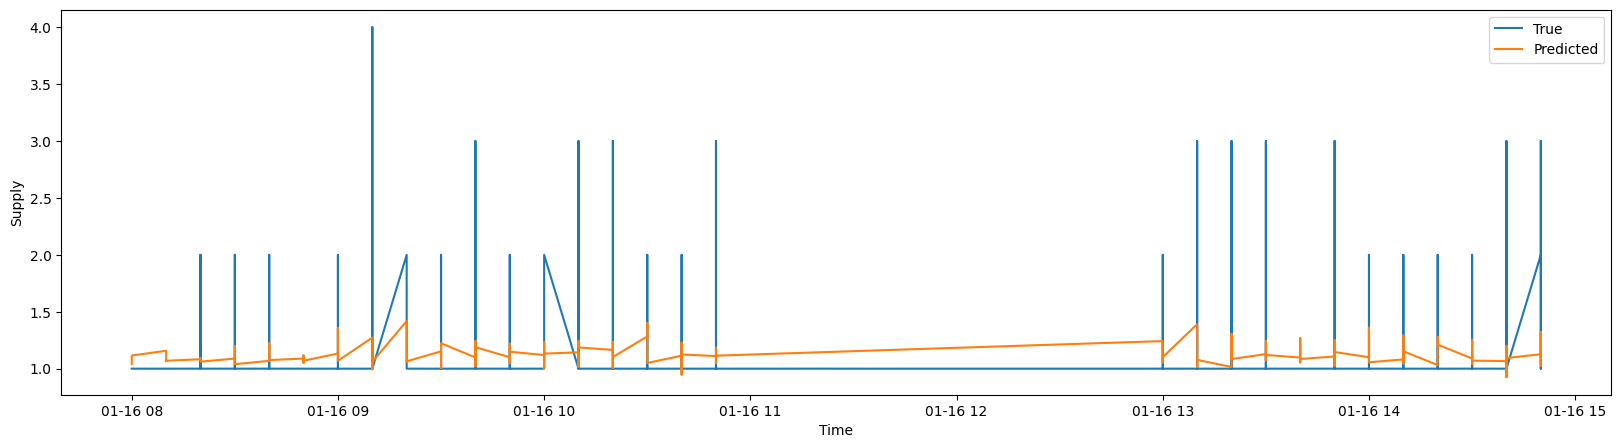

In [101]:
# plot_df = test_df[test_df['hex_id']=='8765b5644ffffff']

# plot_df = test_df[test_df['vehicle_type_TRICYCLE']==True]
test_df['date'] = pd.to_datetime(test_df['date'])

plot_df = test_df.copy()
plot_df = plot_df[plot_df['date']=='2026-01-16']

plt.figure(figsize=(20, 5))
plt.plot(plot_df['block_start_time'], plot_df['total_demands'], label='True')
plt.plot(plot_df['block_start_time'], plot_df['y_pred'], label='Predicted')
plt.xlabel('Time')
plt.ylabel('Supply')
plt.legend()
plt.show()

/var/folders/f5/j3qvvd4923z_49cvx7kg0qnh0000gn/T/ipykernel_33934/1500639022.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='Blues_d')


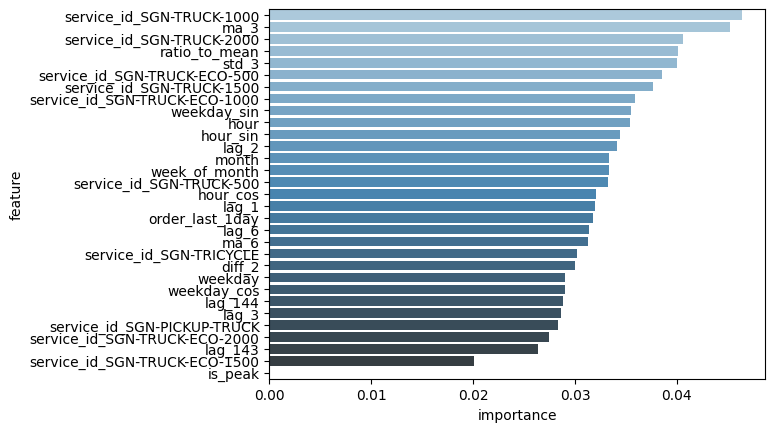

In [102]:
importance = xgb_model_peak_top.feature_importances_

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feat_imp, palette='Blues_d')
plt.show()

#### MIDDLE:

In [103]:
data_middle = data[data['tier']=='MIDDLE']
data_middle_filter = data_top[['block_start_time','hex_id','service_id','total_demands','order_last_1day']]
df_middle_template = demand_fill_time_template(data_top_filter, data_top_filter['block_start_time'].min(), data_top_filter['block_start_time'].max(), '10min')
data_middle_eng = demand_feature_engineering(df_top_template)

data_middle_imp = impute_missing_values(data_middle_eng)
train_df, test_df = split_train_test_time(data_middle_imp, 0.8, 1)


2025-11-02 → 2026-01-13
2026-01-14 → 2026-02-01


In [104]:
train_encode_df = pd.get_dummies(train_df, columns = ['service_id'])
train_encode_df.drop(columns = ['block_start_time','hex_id','date'],inplace=True)

In [105]:
X = train_encode_df.drop(columns = ['total_demands'])
y = train_encode_df['total_demands']

In [106]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

xgb_model_peak_middle = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_peak_middle.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [107]:
test_encode_df = pd.get_dummies(test_df, columns = ['service_id'])
test_encode_df.drop(columns = ['block_start_time','hex_id','date'],inplace=True)

In [108]:
X_test = test_encode_df.drop(columns = ['total_demands'])
y_test = test_encode_df['total_demands']

y_pred_middle = xgb_model_peak_middle.predict(X_test)

In [109]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred_middle)
mse = mean_squared_error(y_test, y_pred_middle)

print("R2:", r2)
print("MSE:", mse)

wape_value = wape(y_test, y_pred_middle)
print(wape_value)

R2: -0.01892727659471971
MSE: 0.16418286010190283
20.385466140099258


#### LOW: 

In [134]:
data_low = data[data['tier']=='LOW']
data_low_filter = data_low[['block_start_time','hex_id','service_id','total_demands','order_last_1day']]
df_low_template = demand_fill_time_template(data_low_filter, data_low_filter['block_start_time'].min(), data_low_filter['block_start_time'].max(), '10min')
data_low_eng = demand_feature_engineering(df_low_template)

data_low_imp = impute_missing_values(data_low_eng)

df_encode_low = pd.get_dummies(data_low_imp, columns = ['service_id'])
train_df, test_df = split_train_test_time(df_encode_low, 0.8, 1)


2025-11-02 → 2026-01-13
2026-01-14 → 2026-02-01


In [136]:
# train_encode_df = pd.get_dummies(train_df, columns = ['service_id'])
train_df.drop(columns = ['block_start_time','hex_id','date'],inplace=True)

X = train_encode_df.drop(columns = ['total_demands'])
y = train_encode_df['total_demands']

In [137]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

xgb_model_peak_low = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_peak_low.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [138]:
# test_encode_df = pd.get_dummies(test_df, columns = ['service_id'])
test_df.drop(columns = ['block_start_time','hex_id','date'],inplace=True)

In [140]:
X_test = test_df.drop(columns = ['total_demands'])
y_test = test_df['total_demands']

y_pred_low = xgb_model_peak_low.predict(X_test)

In [142]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred_low)
mse = mean_squared_error(y_test, y_pred_low)

print("R2:", r2)
print("MSE:", mse)

wape_value = wape(y_test, y_pred_low)
print(wape_value)

R2: -0.2242165575201236
MSE: 0.1153842878434447
14.911518375116078
